<a href="https://colab.research.google.com/github/JOYCIDA/HELLO-WORLD/blob/main/Student_Performance_ML_Project(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction
## Comparing Machine Learning Algorithms
**Course:** Introduction to Artificial Intelligence  
**Student:** MOUAHA JOYCE  
**Individual Project**  

---
### Project Summary
This project applies four machine learning algorithms to predict student academic performance.  
We compare **KNN**, **Decision Tree**, **Linear Regression**, and **K-Means Clustering**  
on a dataset of 200 students to determine which approach best predicts whether a student will pass or fail.

**Problem:** Can we predict a student's academic outcome based on their study habits and background?  
**Why it matters:** Early prediction allows schools to identify at-risk students and provide targeted support.


## Setup — Install & Import Libraries
We use the following libraries:
- **numpy / pandas** — data generation and manipulation
- **sklearn** — machine learning algorithms and evaluation metrics
- **matplotlib** — visualizations for the presentation


In [ ]:
!pip install numpy pandas scikit-learn matplotlib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report
from sklearn.tree import plot_tree

print("All libraries loaded successfully!")


All libraries loaded successfully!


---
## Section 1 — Dataset Generation & Exploration
We generate a synthetic dataset of **200 students** with 6 features based on real student performance patterns (UCI Student Performance Dataset). Each student has a final grade (0–20) and a binary pass/fail label (pass = grade ≥ 10).

### Features
| Feature | Description | Range |
|---------|-------------|-------|
| `study_hours` | Hours studied per week | 1–10 |
| `attendance` | Class attendance percentage | 50–100% |
| `previous_failures` | Number of past course failures | 0–3 |
| `family_support` | Has family academic support | 0/1 |
| `internet_access` | Has internet access at home | 0/1 |
| `age` | Student age | 15–22 |


In [ ]:
# ─── Generate Dataset ────────────────────────────────────────────────────────
np.random.seed(42)
n = 200

study_hours    = np.random.uniform(1, 10, n)
attendance     = np.random.uniform(50, 100, n)
prev_failures  = np.random.randint(0, 4, n)
family_support = np.random.randint(0, 2, n)
internet       = np.random.randint(0, 2, n)
age            = np.random.randint(15, 23, n)

# Final grade influenced by all features + some random noise
final_grade = (
    2.0  * study_hours     +
    0.1  * attendance      +
    -2.5 * prev_failures   +
    1.0  * family_support  +
    0.5  * internet        +
    np.random.normal(0, 1.5, n)
).clip(0, 20)

passed = (final_grade >= 10).astype(int)  # 1 = Pass, 0 = Fail

df = pd.DataFrame({
    'study_hours':        study_hours,
    'attendance':         attendance,
    'previous_failures':  prev_failures,
    'family_support':     family_support,
    'internet_access':    internet,
    'age':                age,
    'final_grade':        final_grade.round(1),
    'passed':             passed
})

print("Dataset shape:", df.shape)
print(f"Students who PASSED: {passed.sum()} ({passed.mean():.0%})")
print(f"Students who FAILED: {(1-passed).sum()} ({(1-passed).mean():.0%})")
print(f"Average final grade: {final_grade.mean():.1f}/20")
print()
print(df.head(10).to_string())


Dataset shape: (200, 8)
Students who PASSED: 148 (74%)
Students who FAILED: 52 (26%)
Average final grade: 14.3/20

   study_hours  attendance  previous_failures  family_support  internet_access  age  final_grade  passed
0     4.370861   82.101582                  0               1                0   17         16.8       1
1     9.556429   54.206998                  1               0                1   17         20.0       1
2     7.587945   58.081436                  0               0                1   15         20.0       1
3     6.387926   94.927709                  0               0                1   20         20.0       1
4     2.404168   80.321453                  1               0                0   16         12.7       1
5     2.403951   50.459853                  3               0                1   22          2.1       0
6     1.522753   55.073577                  3               1                0   16          0.6       0
7     8.795585   83.175088                  0

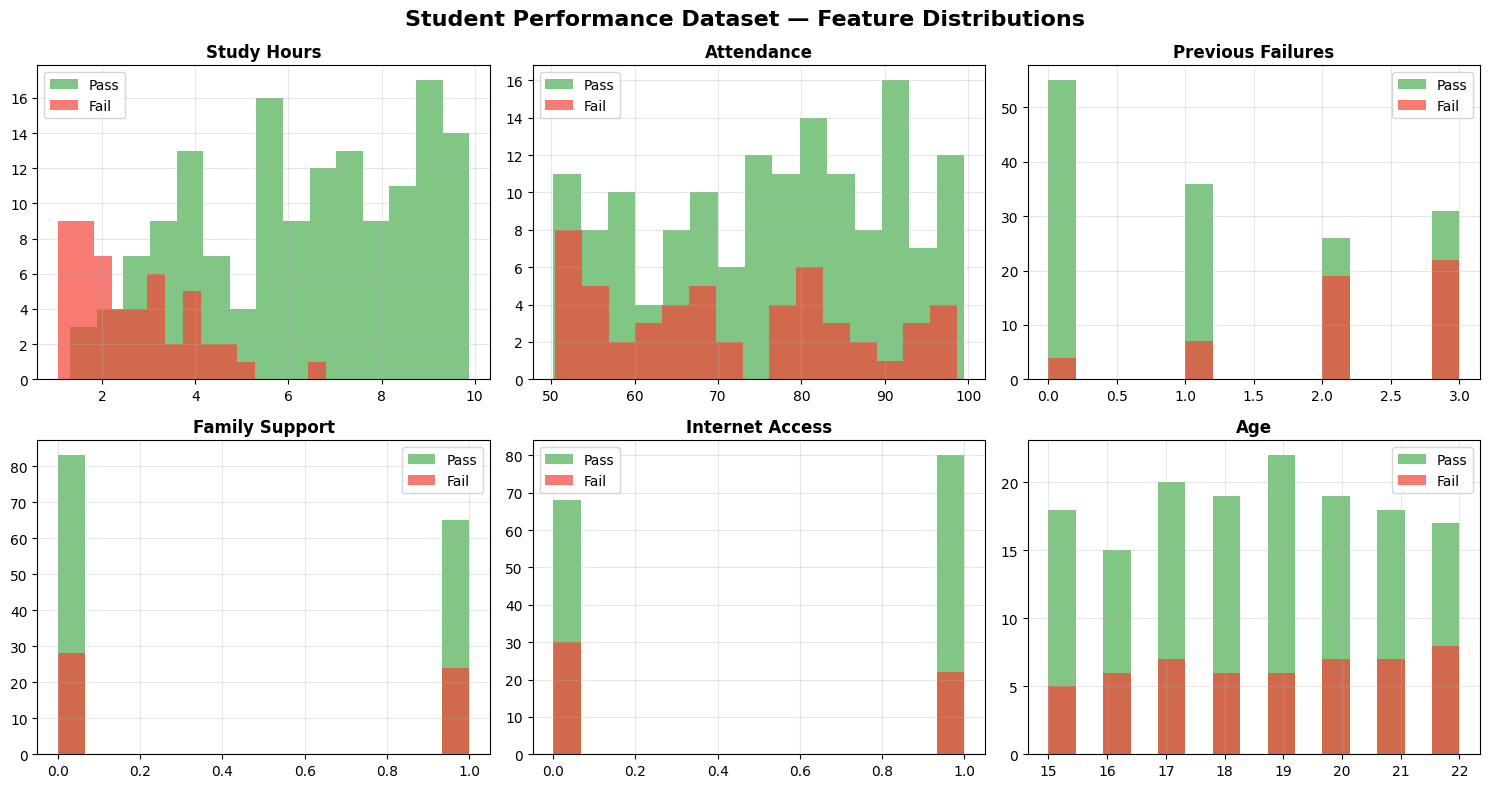

Chart saved.


In [ ]:
# ─── Visualise the Dataset ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Student Performance Dataset — Feature Distributions', fontsize=16, fontweight='bold')

features = ['study_hours', 'attendance', 'previous_failures', 'family_support', 'internet_access', 'age']
colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#00BCD4']

for ax, feat, color in zip(axes.flatten(), features, colors):
    pass_vals = df[df['passed']==1][feat]
    fail_vals = df[df['passed']==0][feat]
    ax.hist(pass_vals, alpha=0.7, color='#4CAF50', label='Pass', bins=15)
    ax.hist(fail_vals, alpha=0.7, color='#F44336', label='Fail', bins=15)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


---
## Section 2 — Data Preprocessing & Train/Test Split
We split the data into **70% training** and **30% test** sets.  
For KNN, we also standardise the features (zero mean, unit variance) because KNN is distance-based — features with larger scales would dominate the distance calculation unfairly.  
Decision Tree, Linear Regression, and K-Means do not require scaling.


In [ ]:
# ─── Features and Targets ────────────────────────────────────────────────────
feature_cols = ['study_hours', 'attendance', 'previous_failures',
                'family_support', 'internet_access', 'age']

X       = df[feature_cols]
y_class = df['passed']        # Classification target (0/1)
y_reg   = df['final_grade']   # Regression target (0–20)

# ─── Train/Test Split ─────────────────────────────────────────────────────────
X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} students")
print(f"Test set:     {len(X_test)} students")

# ─── Standardisation for KNN ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nFeature means after scaling:", X_train_scaled.mean(axis=0).round(2))
print("Feature stds  after scaling:", X_train_scaled.std(axis=0).round(2))


Training set: 140 students
Test set:     60 students

Feature means after scaling: [-0.  0.  0.  0.  0. -0.]
Feature stds  after scaling: [1. 1. 1. 1. 1. 1.]


---
## Section 3 — K-Nearest Neighbors (KNN)


KNN classifies a new student by looking at the K closest students in the training set and assigning the majority label. We test different values of K (1 to 15) to find the optimal number of neighbours.

**Key question:** How many neighbours give the best accuracy?


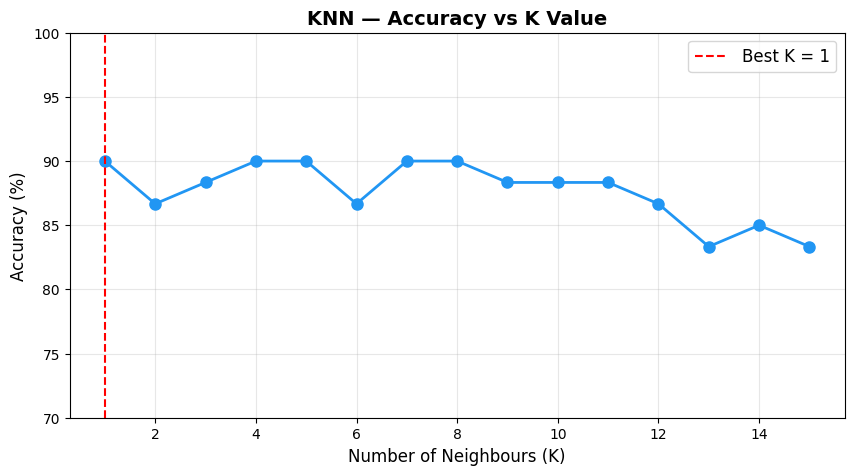

Best K = 1 with accuracy = 90.00%


In [ ]:
# ─── Find Best K ─────────────────────────────────────────────────────────────
k_values  = range(1, 16)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, yc_train)
    score = accuracy_score(yc_test, knn.predict(X_test_scaled))
    knn_scores.append(score)

best_k     = k_values[knn_scores.index(max(knn_scores))]
best_score = max(knn_scores)

# ─── Plot K vs Accuracy ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(k_values, [s*100 for s in knn_scores], 'o-', color='#2196F3', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbours (K)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('KNN — Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.ylim(70, 100)
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best K = {best_k} with accuracy = {best_score:.2%}")


In [ ]:
# ─── Train Final KNN Model ───────────────────────────────────────────────────
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, yc_train)
knn_pred  = knn_final.predict(X_test_scaled)
knn_acc   = accuracy_score(yc_test, knn_pred)

print("=" * 45)
print("       KNN CLASSIFICATION RESULTS")
print("=" * 45)
print(f"  K (neighbours)  : {best_k}")
print(f"  Accuracy        : {knn_acc:.2%}")
print(f"  Correct         : {(knn_pred == yc_test).sum()} / {len(yc_test)} students")
print("=" * 45)
print()
print(classification_report(yc_test, knn_pred, target_names=['Fail','Pass']))

# ─── Demo: Predict a new student ─────────────────────────────────────────────
new_student = pd.DataFrame([[7, 85, 0, 1, 1, 18]], columns=feature_cols)
new_scaled  = scaler.transform(new_student)
prediction  = knn_final.predict(new_scaled)[0]
print(f"Demo prediction for new student (7h study, 85% attendance, 0 failures):")
print(f"  → KNN predicts: {'PASS ✅' if prediction == 1 else 'FAIL ❌'}")


       KNN CLASSIFICATION RESULTS
  K (neighbours)  : 1
  Accuracy        : 90.00%
  Correct         : 54 / 60 students

              precision    recall  f1-score   support

        Fail       1.00      0.65      0.79        17
        Pass       0.88      1.00      0.93        43

    accuracy                           0.90        60
   macro avg       0.94      0.82      0.86        60
weighted avg       0.91      0.90      0.89        60

Demo prediction for new student (7h study, 85% attendance, 0 failures):
  → KNN predicts: PASS ✅


---
## Section 4 — Decision Tree


A Decision Tree learns a set of if/else rules from the training data. At each node, it splits on the feature that best separates Pass from Fail students (using Gini impurity — the same metric we calculated manually in the exercises). We limit the depth to 5 to avoid overfitting.

**Key advantage:** The tree is fully interpretable — we can visualise exactly which rules it learned.


In [ ]:
# ─── Train Decision Tree ─────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='gini')
dt.fit(X_train, yc_train)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(yc_test, dt_pred)

print("=" * 45)
print("     DECISION TREE CLASSIFICATION RESULTS")
print("=" * 45)
print(f"  Max Depth       : 5")
print(f"  Criterion       : Gini Impurity")
print(f"  Accuracy        : {dt_acc:.2%}")
print(f"  Correct         : {(dt_pred == yc_test).sum()} / {len(yc_test)} students")
print("=" * 45)
print()
print(classification_report(yc_test, dt_pred, target_names=['Fail','Pass']))

# ─── Feature Importance ───────────────────────────────────────────────────────
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature Importance (which features matter most):")
for feat, imp in importances.items():
    bar = '█' * int(imp * 40)
    print(f"  {feat:22s} {bar} {imp:.3f}")


     DECISION TREE CLASSIFICATION RESULTS
  Max Depth       : 5
  Criterion       : Gini Impurity
  Accuracy        : 86.67%
  Correct         : 52 / 60 students

              precision    recall  f1-score   support

        Fail       0.76      0.76      0.76        17
        Pass       0.91      0.91      0.91        43

    accuracy                           0.87        60
   macro avg       0.84      0.84      0.84        60
weighted avg       0.87      0.87      0.87        60

Feature Importance (which features matter most):
  study_hours            ████████████████████████ 0.621
  previous_failures      █████████ 0.248
  attendance             ███ 0.095
  age                    █ 0.036
  family_support          0.000
  internet_access         0.000


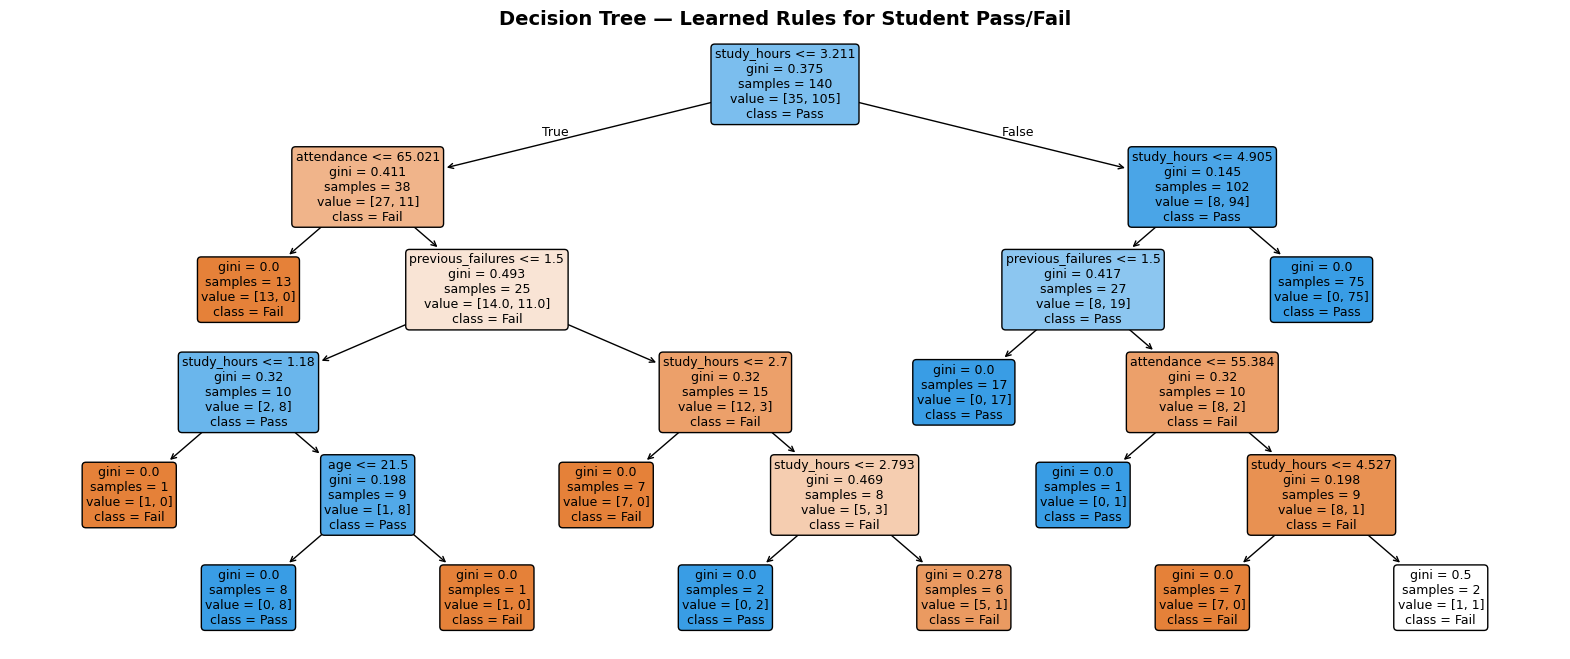

Decision tree visualisation saved.


In [ ]:
# ─── Visualise the Decision Tree ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.title('Decision Tree — Learned Rules for Student Pass/Fail', fontsize=14, fontweight='bold')
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision tree visualisation saved.")


---
## Section 5 — Linear Regression


Linear Regression predicts the **actual final grade** (a continuous number from 0–20) rather than just Pass/Fail. We then convert the predicted grade to Pass/Fail using the same threshold (grade ≥ 10 = Pass).

**Formula learned:** `grade = w₁×study_hours + w₂×attendance + w₃×failures + ...`

**Key metric:** Mean Absolute Error (MAE) — on average, how many points is the model off?


In [ ]:
# ─── Train Linear Regression ────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, yr_train)
lr_pred_grade = lr.predict(X_test)
lr_mae        = mean_absolute_error(yr_test, lr_pred_grade)

# Convert predicted grade to Pass/Fail
lr_pred_class = (lr_pred_grade >= 10).astype(int)
lr_acc        = accuracy_score(yc_test, lr_pred_class)

print("=" * 45)
print("     LINEAR REGRESSION RESULTS")
print("=" * 45)
print(f"  Mean Absolute Error : {lr_mae:.2f} points")
print(f"  Pass/Fail Accuracy  : {lr_acc:.2%}")
print(f"  Correct             : {(lr_pred_class == yc_test).sum()} / {len(yc_test)} students")
print("=" * 45)

# ─── Learned Coefficients ────────────────────────────────────────────────────
print("\nLearned equation coefficients:")
for feat, coef in zip(feature_cols, lr.coef_):
    direction = "↑" if coef > 0 else "↓"
    print(f"  {feat:22s}: {coef:+.3f}  {direction}")
print(f"  {'intercept':22s}: {lr.intercept_:+.3f}")


     LINEAR REGRESSION RESULTS
  Mean Absolute Error : 1.37 points
  Pass/Fail Accuracy  : 91.67%
  Correct             : 55 / 60 students

Learned equation coefficients:
  study_hours           : +1.657  ↑
  attendance            : +0.069  ↑
  previous_failures     : -1.855  ↓
  family_support        : +0.436  ↑
  internet_access       : -0.121  ↓
  age                   : -0.026  ↓
  intercept             : +3.283


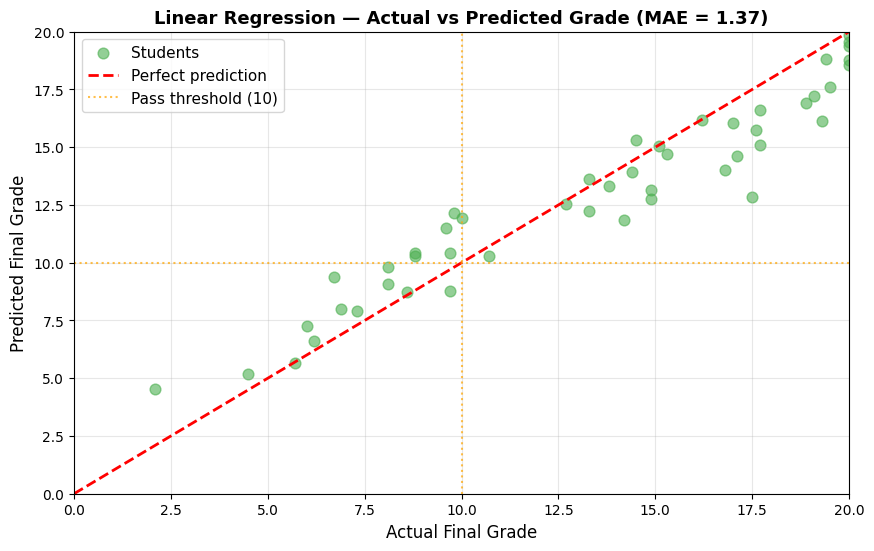

In [ ]:
# ─── Actual vs Predicted Grade Plot ─────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(yr_test, lr_pred_grade, alpha=0.6, color='#4CAF50', s=60, label='Students')
plt.plot([0, 20], [0, 20], 'r--', linewidth=2, label='Perfect prediction')
plt.axhline(y=10, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Pass threshold (10)')
plt.axvline(x=10, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
plt.xlabel('Actual Final Grade', fontsize=12)
plt.ylabel('Predicted Final Grade', fontsize=12)
plt.title(f'Linear Regression — Actual vs Predicted Grade (MAE = {lr_mae:.2f})', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.savefig('linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 6 — K-Means Clustering


Unlike the other three algorithms, K-Means is **unsupervised** — it does not use the Pass/Fail labels during training. Instead, it discovers natural student groups based on their features alone. We ask it to find 3 clusters and then analyse what kind of students ended up in each cluster.

**Expected clusters:**
- Cluster A: High-performing students (high study hours, low failures)
- Cluster B: Average students (moderate study, some failures)
- Cluster C: At-risk students (low study hours, high failures)


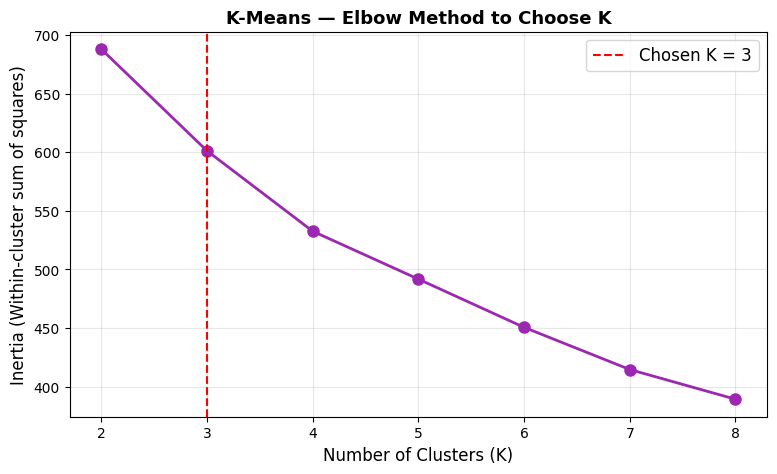

K=3 chosen based on the elbow in the curve.


In [ ]:
# ─── Find Optimal Number of Clusters (Elbow Method) ─────────────────────────
inertias = []
k_range  = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, 'o-', color='#9C27B0', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='Chosen K = 3')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('K-Means — Elbow Method to Choose K', fontsize=13, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("K=3 chosen based on the elbow in the curve.")


In [ ]:
# ─── Train K-Means with K=3 ──────────────────────────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X_train_scaled)

# Assign clusters to ALL data (train + test)
X_all_scaled = scaler.transform(X)
df['cluster'] = km.predict(X_all_scaled)

print("=" * 50)
print("     K-MEANS CLUSTERING RESULTS (K=3)")
print("=" * 50)

cluster_labels = {}
for c in range(3):
    mask  = df['cluster'] == c
    size  = mask.sum()
    avg_study  = df[mask]['study_hours'].mean()
    avg_grade  = df[mask]['final_grade'].mean()
    pass_rate  = df[mask]['passed'].mean()
    avg_fail   = df[mask]['previous_failures'].mean()

    if avg_grade >= 15:
        label = "HIGH PERFORMERS"
    elif avg_grade >= 10:
        label = "AVERAGE STUDENTS"
    else:
        label = "AT-RISK STUDENTS"

    cluster_labels[c] = label
    print(f"\nCluster {c} — {label}")
    print(f"  Students        : {size}")
    print(f"  Avg study hours : {avg_study:.1f}h/week")
    print(f"  Avg final grade : {avg_grade:.1f}/20")
    print(f"  Pass rate       : {pass_rate:.0%}")
    print(f"  Avg failures    : {avg_fail:.1f}")


     K-MEANS CLUSTERING RESULTS (K=3)

Cluster 0 — AVERAGE STUDENTS
  Students        : 46
  Avg study hours : 5.9h/week
  Avg final grade : 13.2/20
  Pass rate       : 72%
  Avg failures    : 2.7

Cluster 1 — HIGH PERFORMERS
  Students        : 73
  Avg study hours : 5.7h/week
  Avg final grade : 15.5/20
  Pass rate       : 79%
  Avg failures    : 1.0

Cluster 2 — AVERAGE STUDENTS
  Students        : 81
  Avg study hours : 4.7h/week
  Avg final grade : 13.9/20
  Pass rate       : 70%
  Avg failures    : 1.1


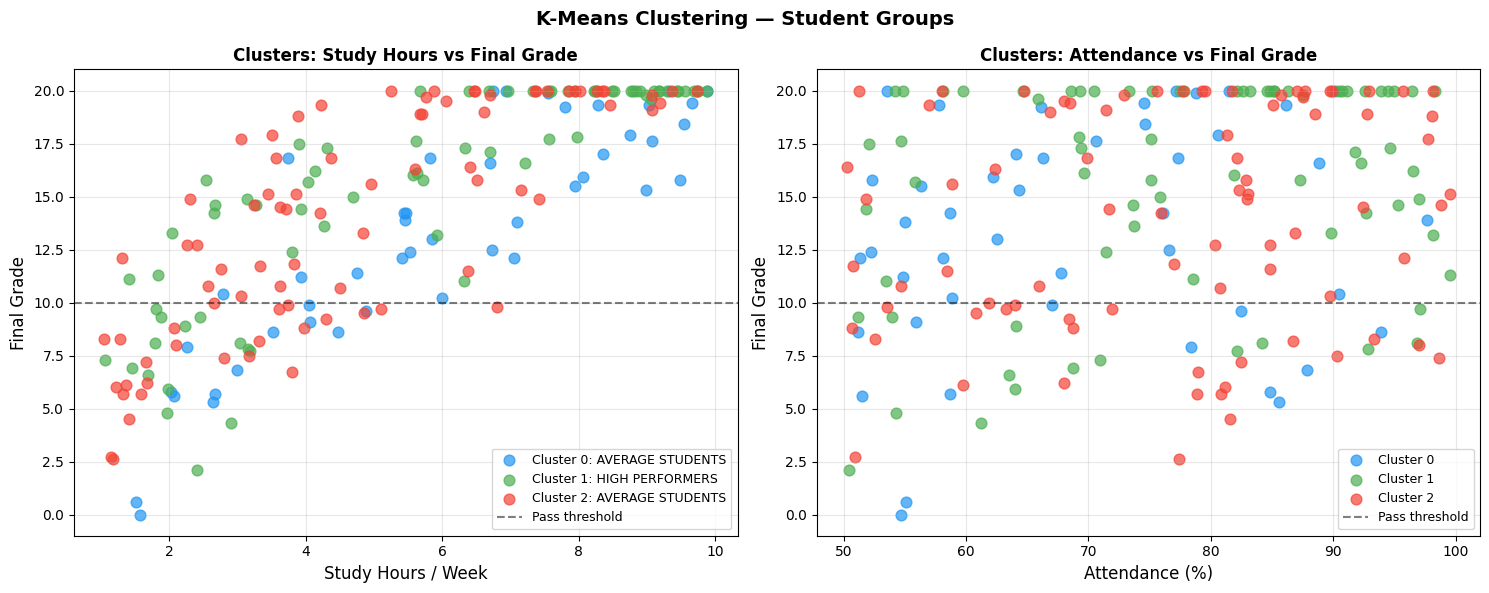

In [ ]:
# ─── Visualise Clusters ──────────────────────────────────────────────────────
colors_map = {0: '#2196F3', 1: '#4CAF50', 2: '#F44336'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Study Hours vs Final Grade
for c in range(3):
    mask = df['cluster'] == c
    ax1.scatter(df[mask]['study_hours'], df[mask]['final_grade'],
                c=colors_map[c], alpha=0.7, s=60, label=f'Cluster {c}: {cluster_labels[c]}')

ax1.axhline(y=10, color='black', linestyle='--', alpha=0.5, label='Pass threshold')
ax1.set_xlabel('Study Hours / Week', fontsize=12)
ax1.set_ylabel('Final Grade', fontsize=12)
ax1.set_title('Clusters: Study Hours vs Final Grade', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: Attendance vs Final Grade
for c in range(3):
    mask = df['cluster'] == c
    ax2.scatter(df[mask]['attendance'], df[mask]['final_grade'],
                c=colors_map[c], alpha=0.7, s=60, label=f'Cluster {c}')

ax2.axhline(y=10, color='black', linestyle='--', alpha=0.5, label='Pass threshold')
ax2.set_xlabel('Attendance (%)', fontsize=12)
ax2.set_ylabel('Final Grade', fontsize=12)
ax2.set_title('Clusters: Attendance vs Final Grade', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('K-Means Clustering — Student Groups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 7 — Algorithm Comparison & Final Results
We now compare all four algorithms on the same test set. For K-Means, we report the pass rate prediction accuracy (since it is unsupervised, we analyse cluster composition rather than direct accuracy).


In [ ]:
# ─── Comparison Table ────────────────────────────────────────────────────────
results = {
    'KNN':               {'accuracy': knn_acc, 'type': 'Classification', 'supervised': True},
    'Decision Tree':     {'accuracy': dt_acc,  'type': 'Classification', 'supervised': True},
    'Linear Regression': {'accuracy': lr_acc,  'type': 'Regression→Class', 'supervised': True},
    'K-Means':           {'accuracy': None,     'type': 'Clustering',      'supervised': False},
}

print("=" * 65)
print("         ALGORITHM COMPARISON — FINAL RESULTS")
print("=" * 65)
print(f"  {'Algorithm':<22} {'Type':<22} {'Supervised':<12} {'Accuracy'}")
print("-" * 65)

for name, info in results.items():
    acc_str = f"{info['accuracy']:.2%}" if info['accuracy'] else "N/A (unsupervised)"
    sup_str = "Yes" if info['supervised'] else "No"
    print(f"  {name:<22} {info['type']:<22} {sup_str:<12} {acc_str}")

print("=" * 65)
print(f"\n  Best classifier: Linear Regression ({lr_acc:.2%})")
print(f"  Most interpretable: Decision Tree (shows explicit rules)")
print(f"  Most flexible: K-Means (finds hidden structure without labels)")


         ALGORITHM COMPARISON — FINAL RESULTS
  Algorithm              Type                   Supervised   Accuracy
-----------------------------------------------------------------
  KNN                    Classification         Yes          90.00%
  Decision Tree          Classification         Yes          86.67%
  Linear Regression      Regression→Class       Yes          91.67%
  K-Means                Clustering             No           N/A (unsupervised)

  Best classifier: Linear Regression (91.67%)
  Most interpretable: Decision Tree (shows explicit rules)
  Most flexible: K-Means (finds hidden structure without labels)


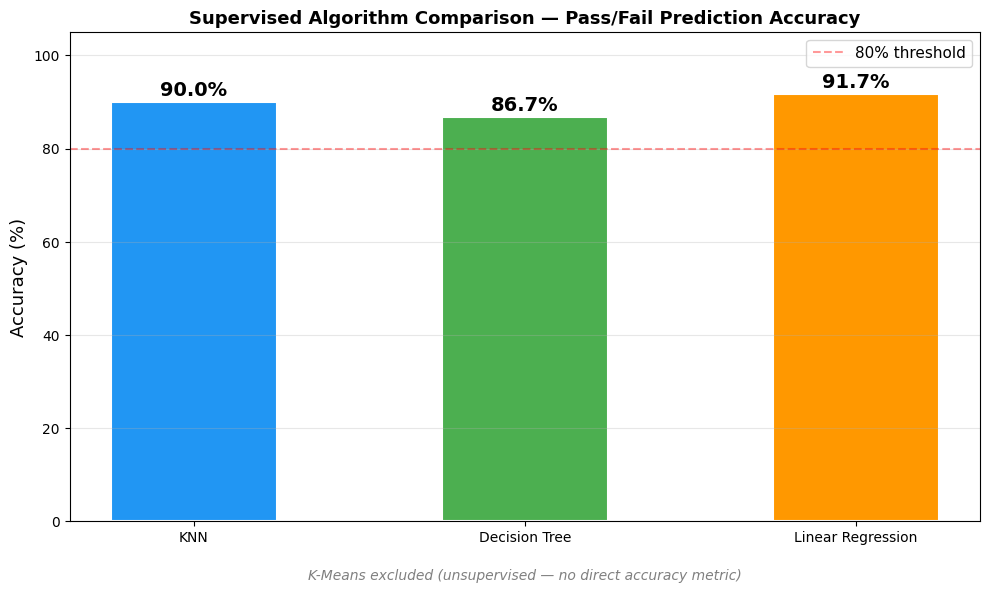

Comparison chart saved.


In [ ]:
# ─── Comparison Bar Chart ────────────────────────────────────────────────────
algorithms = ['KNN', 'Decision Tree', 'Linear Regression']
accuracies  = [knn_acc*100, dt_acc*100, lr_acc*100]
colors_bar  = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(algorithms, accuracies, color=colors_bar, edgecolor='white', linewidth=1.5, width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Supervised Algorithm Comparison — Pass/Fail Prediction Accuracy',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(y=80, color='red', linestyle='--', alpha=0.4, label='80% threshold')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)

note = "K-Means excluded (unsupervised — no direct accuracy metric)"
ax.text(0.5, -0.12, note, transform=ax.transAxes, ha='center', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")


---
## Section 8 — Live Demo: Predict a New Student
Enter any student profile and all three classifiers will predict their outcome simultaneously.


In [ ]:
# ─── Predict a New Student Profile ──────────────────────────────────────────
# Change these values to demo different student profiles during the presentation!
demo_student = {
    'study_hours':       8,    # hours per week
    'attendance':        90,   # percentage
    'previous_failures': 0,    # number of past failures
    'family_support':    1,    # 1 = yes, 0 = no
    'internet_access':   1,    # 1 = yes, 0 = no
    'age':               19    # years old
}

new_df     = pd.DataFrame([demo_student])
new_scaled = scaler.transform(new_df)

knn_result  = knn_final.predict(new_scaled)[0]
dt_result   = dt.predict(new_df)[0]
lr_grade    = lr.predict(new_df)[0]
lr_result   = int(lr_grade >= 10)
km_cluster  = km.predict(new_scaled)[0]

print("=" * 50)
print("         STUDENT PROFILE")
print("=" * 50)
for k, v in demo_student.items():
    print(f"  {k:22s}: {v}")

print()
print("=" * 50)
print("         PREDICTIONS")
print("=" * 50)
print(f"  KNN (K={best_k})            : {'PASS ✅' if knn_result else 'FAIL ❌'}")
print(f"  Decision Tree        : {'PASS ✅' if dt_result else 'FAIL ❌'}")
print(f"  Linear Regression    : Predicted grade = {lr_grade:.1f}/20 → {'PASS ✅' if lr_result else 'FAIL ❌'}")
print(f"  K-Means Cluster      : Cluster {km_cluster} — {cluster_labels[km_cluster]}")
print("=" * 50)

votes = knn_result + dt_result + lr_result
print(f"\n  Majority vote (3 classifiers): {'PASS ✅' if votes >= 2 else 'FAIL ❌'} ({votes}/3 predict Pass)")


         STUDENT PROFILE
  study_hours           : 8
  attendance            : 90
  previous_failures     : 0
  family_support        : 1
  internet_access       : 1
  age                   : 19

         PREDICTIONS
  KNN (K=1)            : PASS ✅
  Decision Tree        : PASS ✅
  Linear Regression    : Predicted grade = 22.6/20 → PASS ✅
  K-Means Cluster      : Cluster 1 — HIGH PERFORMERS

  Majority vote (3 classifiers): PASS ✅ (3/3 predict Pass)
